# Rediscover the Higgs Boson — Guided Practice Notebook

This notebook follows the same analysis path as **HyyAnalysis.ipynb** —
rediscovering the Higgs boson in the $H\rightarrow\gamma\gamma$ decay channel using
ATLAS Open Data — but breaks the journey into many smaller **tasks** that you
should complete yourself.

> **How to use this notebook**
>
> Every task is clearly marked with a coloured banner:
>
> <div class="alert alert-block alert-warning">
> <b>>>></b> TASK — short description
> </div>
>
> The solution code is provided right below each task so that you can check your
> work.  When doing the exercise yourself, clear the solution cells first and
> write your own implementation.
>
> Cells that are **not** part of a task (setup, data access, plotting utilities)
> should simply be run as-is.

**Learning objectives**
1. Understand and implement analysis selections (cuts) on ATLAS open data.
2. Quantify the effect of each cut with a cut-flow table.
3. Study the di-photon invariant mass spectrum before and after selections.
4. Fit the background with a polynomial and the signal with a Gaussian.
5. Evaluate fit quality with residuals and reduced $\chi^2$.
6. Estimate the size of the Higgs excess in events and as a simple significance.
7. Reason about setting a limit with and without a signal.

---

## Table of Contents
1. [Setup & Data Access](#setup)
2. [Task 1 — Explore the TTree](#task1)
3. [Task 2 — Define the cut functions](#task2)
4. [Task 3 — Apply cuts to a single batch](#task3)
5. [Task 4 — Cut-flow table](#task4)
6. [Task 5 — Invariant mass of a single event](#task5)
7. [Task 6 — Histogram the data after cuts](#task6)
8. [Task 7 — Background-only fit](#task7)
9. [Task 8 — Signal+background fit](#task8)
10. [Task 9 — Residuals and reduced $\chi^2$](#task9)
11. [Task 10 — Signal yield and excess estimate](#task10)
12. [Task 11 — Sideband cross-check](#task11)
13. [Task 12 — Limit-setting reasoning](#task12)
14. [Task 13 — Optional: vary a cut](#task13)


<a id='setup'></a>
## 1. Setup & Data Access

We import the usual python packages and initialise `atlasopenmagic` to access the
ATLAS Open Data portal.

The conda environment **cern_intern_practice** contains all needed packages.

In [2]:
# Core packages
import uproot                 # reading ROOT files
import time                   # timing
import math
import awkward as ak          # jagged arrays
import numpy as np            # numerics
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoMinorLocator
from lmfit.models import PolynomialModel, GaussianModel
import vector                 # 4-vector math

# ATLAS Open Data access
import atlasopenmagic as atom
atom.set_release('2025e-13tev-beta')

print("Setup complete.")


Release '2025e-13tev-beta' already active with cached metadata.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


Setup complete.


### Analysis parameters

* **luminosity** — the total integrated luminosity of the data sample (36.1 fb$^{-1}$).
* **fraction** — fraction of events to process (reduce for speed; set to 1 for full data).


In [ ]:
luminosity = 36.1  # fb^-1
fraction   = 1.0    # 1.0 = all data; 0.5 = half (faster)

# Skim: pre-selected events with >= 2 photons
skim = "GamGam"

# Retrieve data file URLs (cached locally)
files_list = atom.get_urls('data', skim, protocol='https', cache=True)
print(files_list)
print(f"Number of data files: {len(files_list)}")


Number of data files: 16


### Important variables

For the $H\rightarrow\gamma\gamma$ analysis we only need a handful of branches.
The `photon_*` branches store per-photon quantities as variable-length lists
(two entries per event in this skim, ordered by descending $p_T$).


In [ ]:
variables = [
    "photon_pt",            # transverse momentum [GeV]
    "photon_eta",           # pseudorapidity
    "photon_phi",           # azimuthal angle
    "photon_e",             # energy [GeV]
    "photon_isTightID",     # tight identification flag
    "photon_ptcone20",      # track-based isolation variable
]

# For MC we also need weight information
mc_weight_variables = ["mcWeight", "xsec", "kfac", "filteff", "sum_of_weights"]


### Quick look at a single file

Next, let's open the `data15_periodD` file to examine its contents. The file, known as a `tree`, contains multiple entries, each representing an event. For each event, a dictionary stores all relevant information with keys, such as the event number (`eventNumber`), the photon transverse momentum (`photon_pt`), and more.

Details on the variables in the dictionary can be viewed [here](https://cds.cern.ch/record/2707171/files/ANA-OTRC-2019-01-PUB-updated.pdf) in Appendix A.

More information on trees can be viewed [here](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TTree.TTree.html) and [here](https://hsf-training.github.io/hsf-training-uproot-webpage/03-trees/index.html).

In [ ]:
# Accessing the file from the online database (":analysis" opens the tree in a desired manner)
tree = uproot.open(files_list[0] + ":analysis")
print("Entries in file 0:", tree.num_entries)
print("Keys (first 12):", tree.keys()[:12])


Entries in file 0: 63195
Keys (first 12): ['num_events', 'sum_of_weights', 'sum_of_weights_squared', 'category', 'sig_ph', 'n_sig_ph', 'TriggerMatch_DILEPTON', 'ScaleFactor_MLTRIGGER', 'ScaleFactor_PILEUP', 'ScaleFactor_FTAG', 'mcWeight', 'xsec']


<a id='task1'></a>
## 2. Task 1 — Explore the TTree

<div class="alert alert-block alert-warning">
>>>
<b>TASK 1</b> — Using the <code>tree</code> object opened above:
<ol>
<li>Print the transverse momenta (<code>photon_pt</code>) for the first 5 events.</li>
<li>How many events does the first data file contain?  Print the answer.</li>
<li>Access the <code>photon_eta</code> branch and print the first event's two photon &eta; values.</li>
<li>Plot the two photon's in the first event in &eta;, &phi; coordinates and make the size of each photon marker proportional to the photon energy.</li>
</ol>
</div>

In [6]:
# >>> TASK 1 — SOLUTION <<<
# (1) First 5 events' photon_pt
pt_5 = tree["photon_pt"].arrays(library="ak", entry_stop=5)
print("photon_pt for first 5 events:")
for i, ev in enumerate(pt_5):
    print(f"  Event {i}: {ev}")

# (2) Number of events
n = tree.num_entries
print(f"\nFirst data file contains {n} events.")

# (3) First event's photon_eta
eta_0 = tree["photon_eta"].arrays(library="ak", entry_stop=1)[0]
print(f"\nFirst event photon_eta: {eta_0}")


photon_pt for first 5 events:
  Event 0: {photon_pt: [106, 47.6]}
  Event 1: {photon_pt: [41.6, 37.3]}
  Event 2: {photon_pt: [45.2, 42.5]}
  Event 3: {photon_pt: [97.5, 33.5]}
  Event 4: {photon_pt: [112, 71.7]}

First data file contains 63195 events.

First event photon_eta: {photon_eta: [1.66, 0.637]}


<a id='task2'></a>
## 3. Task 2 — Define the cut functions

The analysis requires five cuts.  Each cut returns a **boolean mask** (awkward
array) that is `True` for events that pass the cut and `False` for events that
should be removed.

| Cut | Branch(es) | Requirement |
|-----|-------------|-------------|
| Reconstruction quality | `photon_isTightID` | both photons `True` |
| Transverse momentum | `photon_pt` | leading $p_T>50$ GeV, sub-leading $p_T>30$ GeV |
| Calorimeter isolation | `photon_ptcone20`, `photon_pt` | $pTcone20/pT < 0.055$ for both |
| $\eta$ transition | `photon_eta` | exclude $1.37 < \|\eta\| < 1.52$ |
| $p_T/m$ isolation | `photon_pt`, invariant mass | $p_T/m_{\gamma\gamma} > 0.35$ for both |

<div class="alert alert-block alert-warning">
>>>
<b>TASK 2</b> — Implement the five cut functions below.  Each must accept
awkward arrays (per-event lists of 2 photons) and return a 1-D boolean mask.
The first cut is done for you as an example.
</div>

In [ ]:
# EXAMPLE: Photon reconstruction quality
def cut_photon_reconstruction(photon_isTightID):
    """Keep events where BOTH photons pass Tight ID."""
    return (photon_isTightID[:, 0] == True) & (photon_isTightID[:, 1] == True)

In [ ]:
# >>> TASK 2 — SOLUTION <<<

# --- (a) Photon reconstruction quality ---
def cut_photon_reconstruction(photon_isTightID):
    """Keep events where BOTH photons pass Tight ID."""
    return (photon_isTightID[:, 0] == True) & (photon_isTightID[:, 1] == True)

# --- (b) Transverse momentum ---
def cut_photon_pt(photon_pt):
    """Leading photon pT > 50 GeV, sub-leading pT > 30 GeV."""
    return (photon_pt[:, 0] > 50) & (photon_pt[:, 1] > 30)

# --- (c) Calorimeter isolation ---
def cut_isolation_pt(photon_ptcone20, photon_pt):
    """ptcone20 / pt < 0.055 for both photons."""
    return ((photon_ptcone20[:, 0] / photon_pt[:, 0]) < 0.055) & \
           ((photon_ptcone20[:, 1] / photon_pt[:, 1]) < 0.055)

# --- (d) Eta transition region exclusion ---
def cut_photon_eta_transition(photon_eta):
    """Exclude events in the barrel/end-cap crack: 1.37 < |eta| < 1.52."""
    cond_0 = (np.abs(photon_eta[:, 0]) < 1.52) | (np.abs(photon_eta[:, 0]) > 1.37)
    cond_1 = (np.abs(photon_eta[:, 1]) < 1.52) | (np.abs(photon_eta[:, 1]) > 1.37)
    return cond_0 & cond_1

# --- (e) pT / invariant-mass relative isolation ---
def cut_iso_mass(photon_pt, invariant_mass):
    """pT / m_yy > 0.35 for both photons."""
    return ((photon_pt[:, 0] / invariant_mass) > 0.35) & \
           ((photon_pt[:, 1] / invariant_mass) > 0.35)

# --- helper: invariant mass ---
def calc_mass(photon_pt, photon_eta, photon_phi, photon_e):
    """Calculate the di-photon invariant mass in GeV."""
    p4 = vector.zip({"pt": photon_pt, "eta": photon_eta, "phi": photon_phi, "e": photon_e})
    return (p4[:, 0] + p4[:, 1]).M

# --- helper: remove zero-mass events ---
def cut_mass(invariant_mass):
    """Remove events where the invariant mass is exactly zero."""
    return (invariant_mass != 0)


All cut functions defined.


<a id='task3'></a>
## 4. Task 3 — Apply cuts to a single batch

Before running over all data, let's apply the cuts to a **single batch** from
the first file so we can verify each cut works.

<div class="alert alert-block alert-warning">
>>>
<b>TASK 3</b> — In the cell below:
<ol>
<li>Read one batch of <code>variables</code> from the tree using
<code>tree.iterate(..., entry_stop=500)</code>.</li>
<li>Apply the cuts <b>in order</b>: reconstruction → pT → isolation → eta → mass
calculation → mass-isolation.</li>
<li>Print how many events remain after <b>each</b> cut.</li>
</ol>
</div>

In [8]:
# >>> TASK 3 — SOLUTION <<<
batch = tree.iterate(variables, library="ak", entry_stop=500)
data = next(batch)  # one batch from the iterator
n_start = len(data)
print(f"Events before cuts: {n_start}")

# Cut 1: reconstruction quality
data = data[cut_photon_reconstruction(data['photon_isTightID'])]
print(f"After reconstruction cut:  {len(data)}")

# Cut 2: transverse momentum
data = data[cut_photon_pt(data['photon_pt'])]
print(f"After pT cut:               {len(data)}")

# Cut 3: calorimeter isolation
data = data[cut_isolation_pt(data['photon_ptcone20'], data['photon_pt'])]
print(f"After isolation cut:         {len(data)}")

# Cut 4: eta transition region
data = data[cut_photon_eta_transition(data['photon_eta'])]
print(f"After eta cut:              {len(data)}")

# Calculate invariant mass
data['mass'] = calc_mass(data['photon_pt'], data['photon_eta'],
                          data['photon_phi'], data['photon_e'])
data = data[cut_mass(data['mass'])]
print(f"After null-mass cut:         {len(data)}")

# Cut 5: pT/mass relative isolation
data = data[cut_iso_mass(data['photon_pt'], data['mass'])]
print(f"After pT/mass cut:            {len(data)}")
print(f"Survival fraction:          {len(data)/n_start:.3f}")


Events before cuts: 500
After reconstruction cut:  71
After pT cut:               18
After isolation cut:         10
After eta cut:              10
After null-mass cut:         10
After pT/mass cut:            5
Survival fraction:          0.010


<a id='task4'></a>
## 5. Task 4 — Cut-flow table

A **cut-flow table** shows how many events survive after each successive cut.
This is an important diagnostics in any particle-physics analysis.

<div class="alert alert-block alert-warning">
>>>
<b>TASK 4</b> — Process the <b>entire first data file</b> and record the number
of events remaining after each cut.  Store the counts in a list called
<code>cut_counts</code> and print a formatted table.
</div>

In [9]:
# >>> TASK 4 — SOLUTION <<<
cut_names = [
    "All events",
    "Photon reconstruction (TightID)",
    "Photon pT (50/30 GeV)",
    "Calorimeter isolation",
    "Eta transition exclusion",
    "Null mass removal",
    "pT/m relative isolation",
]

cut_counts = [0, 0, 0, 0, 0, 0, 0]

for data in tree.iterate(variables, library="ak"):
    # before any cuts
    n0 = len(data)
    cut_counts[0] += n0

    data = data[cut_photon_reconstruction(data['photon_isTightID'])]
    cut_counts[1] += len(data)

    data = data[cut_photon_pt(data['photon_pt'])]
    cut_counts[2] += len(data)

    data = data[cut_isolation_pt(data['photon_ptcone20'], data['photon_pt'])]
    cut_counts[3] += len(data)

    data = data[cut_photon_eta_transition(data['photon_eta'])]
    cut_counts[4] += len(data)

    data['mass'] = calc_mass(data['photon_pt'], data['photon_eta'],
                             data['photon_phi'], data['photon_e'])
    data = data[cut_mass(data['mass'])]
    cut_counts[5] += len(data)

    data = data[cut_iso_mass(data['photon_pt'], data['mass'])]
    cut_counts[6] += len(data)

# Print formatted table
print(f"{'Cut':<45} {'Events':>10} {'Rel. efficiency':>18}")
print("-" * 75)
for i, (name, count) in enumerate(zip(cut_names, cut_counts)):
    rel = count / cut_counts[0] if cut_counts[0] > 0 else 0
    print(f"{name:<45} {count:>10} {rel:>17.4f}")


Cut                                               Events    Rel. efficiency
---------------------------------------------------------------------------
All events                                         63195            1.0000
Photon reconstruction (TightID)                     8392            0.1328
Photon pT (50/30 GeV)                               2312            0.0366
Calorimeter isolation                               1240            0.0196
Eta transition exclusion                            1240            0.0196
Null mass removal                                   1240            0.0196
pT/m relative isolation                              790            0.0125


<a id='task5'></a>
## 6. Task 5 — Invariant mass of a single event

The di-photon invariant mass is computed from the 4-momenta of the two photons:

$$m_{\gamma\gamma} = \sqrt{E_{\text{tot}}^2 - \mathbf{p}_{\text{tot}}\cdot\mathbf{p}_{\text{tot}}}$$

using natural units ($c=1$).

<div class="alert alert-block alert-warning">
>>>
<b>TASK 5</b> — For the first event in the first data file, calculate the
invariant mass <b>step by step</b> (do not use the <code>calc_mass</code>
helper).  Print the photon 4-vectors and the resulting mass.
</div>

In [ ]:
# >>> TASK 5 — SOLUTION <<<
first_event = tree.arrays(library="ak")[:1]

# Extract individual photon 4-vector components for the first event
# photons are ordered by descending pT: [0] = leading, [1] = sub-leading
pt0  = first_event['photon_pt'][0, 0]    # transverse momentum of photon 0
pt1  = first_event['photon_pt'][0, 1]    # transverse momentum of photon 1
eta0 = first_event['photon_eta'][0, 0]   # pseudorapidity of photon 0
eta1 = first_event['photon_eta'][0, 1]   # pseudorapidity of photon 1
phi0 = first_event['photon_phi'][0, 0]   # azimuthal angle of photon 0
phi1 = first_event['photon_phi'][0, 1]   # azimuthal angle of photon 1
e0   = first_event['photon_e'][0, 0]      # energy of photon 0
e1   = first_event['photon_e'][0, 1]      # energy of photon 1

print("=== Photon 4-vector components ===")
print(f"  Photon 0:  pt = {pt0:.2f} GeV,  eta = {eta0:.4f},  phi = {phi0:.4f},  E = {e0:.2f} GeV")
print(f"  Photon 1:  pt = {pt1:.2f} GeV,  eta = {eta1:.4f},  phi = {phi1:.4f},  E = {e1:.2f} GeV")

# --- Method 1: Explicit step-by-step calculation ---
# The invariant mass formula is:  m = sqrt(E_tot^2 - |p_tot|^2)
# where E_tot is the total energy and p_tot is the total 3-momentum.
#
# First we need the Cartesian momentum components (px, py, pz) for each photon.
# These are reconstructed from (pt, eta, phi):
#   px = pt * cos(phi)
#   py = pt * sin(phi)
#   pz = pt * sinh(eta)

# Photon 0
px0 = pt0 * math.cos(phi0)
py0 = pt0 * math.sin(phi0)
pz0 = pt0 * math.sinh(eta0)

# Photon 1
px1 = pt1 * math.cos(phi1)
py1 = pt1 * math.sin(phi1)
pz1 = pt1 * math.sinh(eta1)

print("\n--- Method 1: Explicit calculation ---")
print(f"  Photon 0:  px={px0:.2f}, py={py0:.2f}, pz={pz0:.2f} GeV")
print(f"  Photon 1:  px={px1:.2f}, py={py1:.2f}, pz={pz1:.2f} GeV")

# Sum the energy and momentum components
E_tot  = e0 + e1
px_tot = px0 + px1
py_tot = py0 + py1
pz_tot = pz0 + pz1

# Magnitude squared of total 3-momentum: |p_tot|^2 = px^2 + py^2 + pz^2
p_tot_sq = px_tot**2 + py_tot**2 + pz_tot**2

# Invariant mass: m = sqrt(E_tot^2 - |p_tot|^2)
m_explicit = math.sqrt(E_tot**2 - p_tot_sq)

print(f"  Total energy:        E_tot = {E_tot:.2f} GeV")
print(f"  Total momentum:       p_tot = ({px_tot:.2f}, {py_tot:.2f}, {pz_tot:.2f}) GeV")
print(f"  |p_tot|^2 = {p_tot_sq:.2f} GeV^2")
print(f"  E_tot^2    = {E_tot**2:.2f} GeV^2")
print(f"  m = sqrt(E_tot^2 - |p_tot|^2) = {m_explicit:.2f} GeV")

# --- Method 2: Using the vector library's .M property ---
# Build 4-vectors, add them, and read off the invariant mass directly.
p4 = vector.zip({"pt": first_event['photon_pt'], "eta": first_event['photon_eta'],
                 "phi": first_event['photon_phi'], "e": first_event['photon_e']})
photon0 = p4[0, 0]
photon1 = p4[0, 1]
diphoton = photon0 + photon1
m_vector = diphoton.M

print(f"\n--- Method 2: vector library .M ---")
print(f"  (photon0 + photon1).M = {m_vector:.2f} GeV")

# --- Compare the two methods ---
print(f"\n=== Comparison ===")
print(f"  Explicit calculation:  m = {m_explicit:.2f} GeV")
print(f"  vector .M:              m = {m_vector:.2f} GeV")
print(f"  Difference:              {abs(m_explicit - m_vector):.2e} GeV")
print(f"  The two methods agree to floating-point precision.")


In [ ]:
# >>> TASK 5 — SOLUTION <<<
first_event = tree.arrays(library="ak")[:1]

# Photon 4-vectors
pt0, pt1 = first_event['photon_pt'][0, 0], first_event['photon_pt'][0, 1]
e0,  e1  = first_event['photon_e'][0, 0],  first_event['photon_e'][0, 1]

# Build 4-vectors using vector.zip
p4 = vector.zip({"pt": first_event['photon_pt'], "eta": first_event['photon_eta'],
                 "phi": first_event['photon_phi'], "e": first_event['photon_e']})
photon0 = p4[0, 0]
photon1 = p4[0, 1]

print(f"Photon 0: pt={photon0.pt:.2f} GeV, E={photon0.E:.2f} GeV")
print(f"Photon 1: pt={photon1.pt:.2f} GeV, E={photon1.E:.2f} GeV")

# Sum the two 4-vectors and get the invariant mass
diphoton = photon0 + photon1
m = diphoton.M

print(f"\nDi-photon invariant mass = {m:.2f} GeV")


Photon 0: pt=106.27 GeV, E=289.33 GeV
Photon 1: pt=47.58 GeV, E=57.55 GeV

Di-photon invariant mass = 160.48 GeV


<a id='task6'></a>
## 7. Task 6 — Histogram the data after all cuts

Now we process the **full dataset** (all files), apply all cuts, and collect the
invariant masses.  We then histogram the result.

<div class="alert alert-block alert-warning">
>>>
<b>TASK 6</b> — Complete the processing loop.  The skeleton is provided; you
must insert the correct cut calls in the correct order.  After processing, create
a histogram of the invariant mass in the range 100–160 GeV with 1 GeV bins.
</div>

In [11]:
# >>> TASK 6 — SOLUTION <<<
sample_data = []

for afile in files_list:
    print(f'Processing {files_list.index(afile)+1}/{len(files_list)}: {afile.split("/")[-1]}')
    tree = uproot.open(afile + ":analysis")
    numevents = tree.num_entries

    for data in tree.iterate(variables, library="ak",
                             entry_stop=int(numevents * fraction)):
        # Apply cuts in order
        data = data[cut_photon_reconstruction(data['photon_isTightID'])]
        data = data[cut_photon_pt(data['photon_pt'])]
        data = data[cut_isolation_pt(data['photon_ptcone20'], data['photon_pt'])]
        data = data[cut_photon_eta_transition(data['photon_eta'])]

        data['mass'] = calc_mass(data['photon_pt'], data['photon_eta'],
                                 data['photon_phi'], data['photon_e'])
        data = data[cut_mass(data['mass'])]
        data = data[cut_iso_mass(data['photon_pt'], data['mass'])]

        sample_data.append(data['mass'])

print("Done processing all data files.")

# Concatenate all masses into a single array
all_data = ak.concatenate(sample_data)
print(f"Total selected events: {len(all_data)}")


Processing 1/16: ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root
Processing 2/16: ODEO_FEB2025_v0_GamGam_data15_periodE.GamGam.root
Processing 3/16: ODEO_FEB2025_v0_GamGam_data15_periodF.GamGam.root
Processing 4/16: ODEO_FEB2025_v0_GamGam_data15_periodG.GamGam.root
Processing 5/16: ODEO_FEB2025_v0_GamGam_data15_periodH.GamGam.root
Processing 6/16: ODEO_FEB2025_v0_GamGam_data15_periodJ.GamGam.root
Processing 7/16: ODEO_FEB2025_v0_GamGam_data16_periodA.GamGam.root
Processing 8/16: ODEO_FEB2025_v0_GamGam_data16_periodB.GamGam.root
Processing 9/16: ODEO_FEB2025_v0_GamGam_data16_periodC.GamGam.root
Processing 10/16: ODEO_FEB2025_v0_GamGam_data16_periodD.GamGam.root
Processing 11/16: ODEO_FEB2025_v0_GamGam_data16_periodE.GamGam.root
Processing 12/16: ODEO_FEB2025_v0_GamGam_data16_periodF.GamGam.root
Processing 13/16: ODEO_FEB2025_v0_GamGam_data16_periodG.GamGam.root
Processing 14/16: ODEO_FEB2025_v0_GamGam_data16_periodI.GamGam.root
Processing 15/16: ODEO_FEB2025_v0_GamGam_data16_periodK.G

In [12]:
# Histogram configuration
xmin, xmax = 100, 160    # GeV
step_size  = 1           # GeV

bin_edges   = np.arange(start=xmin, stop=xmax + step_size, step=step_size)
bin_centres = np.arange(start=xmin + step_size/2,
                         stop=xmax + step_size/2, step=step_size)

# Histogram the data
data_x, _ = np.histogram(ak.to_numpy(all_data), bins=bin_edges)
# Statistical errors: sqrt(N), protect against empty bins
data_x_errors = np.where(data_x > 0, np.sqrt(data_x), 1e-10)

print(f"Events in histogram (100-160 GeV): {data_x.sum()}")


Events in histogram (100-160 GeV): 251659


### Plot the mass spectrum

This produces the main data histogram (black points).

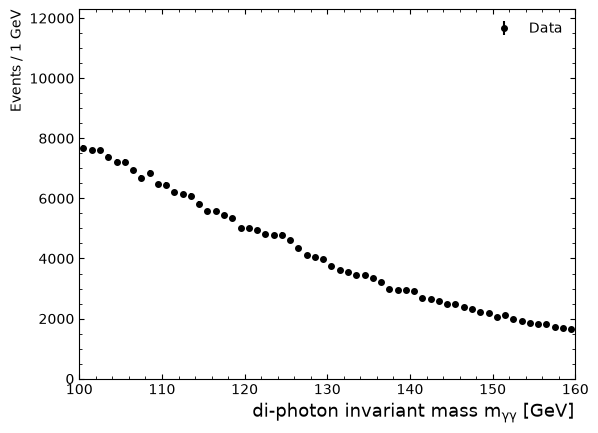

In [13]:
main_axes = plt.gca()
main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
                    fmt='ko', label='Data', markersize=4)
main_axes.set_xlim(left=xmin, right=xmax)
main_axes.xaxis.set_minor_locator(AutoMinorLocator())
main_axes.tick_params(which='both', direction='in', top=True, right=True)
main_axes.set_xlabel(r'di-photon invariant mass $\mathrm{m_{\gamma\gamma}}$ [GeV]',
                      fontsize=13, x=1, horizontalalignment='right')
main_axes.set_ylabel('Events / '+str(step_size)+' GeV', y=1, horizontalalignment='right')
main_axes.set_ylim(bottom=0, top=np.amax(data_x)*1.6)
main_axes.yaxis.set_minor_locator(AutoMinorLocator())
main_axes.legend(frameon=False)
plt.show()


<a id='task6b'></a>
## 8. (Optional) Task 6b — Plotting the mass spectrum

Before proceeding, it could be interesting to look at the invariant mass distribution in different data taking years and periods. In a plot, compare data from 2015 to 2016 and different periods within each. Do you notice any differences?

<div class="alert alert-block alert-warning">
>>>
<b>TASK 6b</b> — Plot the data from different years and periods separately on the same axes with the same x-axis label as above. 
</div>

In [21]:
# >>> TASK 6b — SOLUTION (optional) <<<
# Process each file separately and group by year (2015 vs 2016).
# The filename contains "data15_" or "data16_" so we can extract the year.

data_2015 = []
data_2016 = []

for afile in files_list:
    fname = afile.split("/")[-1]
    print(f'Processing {files_list.index(afile)+1}/{len(files_list)}: {fname}')
    tree = uproot.open(afile + ":analysis")
    numevents = tree.num_entries

    # Determine the data-taking year from the filename
    if 'data15' in fname:
        year = '2015'
    elif 'data16' in fname:
        year = '2016'
    else:
        continue

    for data in tree.iterate(variables, library="ak",
                             entry_stop=int(numevents * fraction)):
        # Apply cuts in order (same as Task 6)
        data = data[cut_photon_reconstruction(data['photon_isTightID'])]
        data = data[cut_photon_pt(data['photon_pt'])]
        data = data[cut_isolation_pt(data['photon_ptcone20'], data['photon_pt'])]
        data = data[cut_photon_eta_transition(data['photon_eta'])]

        data['mass'] = calc_mass(data['photon_pt'], data['photon_eta'],
                                 data['photon_phi'], data['photon_e'])
        data = data[cut_mass(data['mass'])]
        data = data[cut_iso_mass(data['photon_pt'], data['mass'])]

        if year == '2015':
            data_2015.append(data['mass'])
        else:
            data_2016.append(data['mass'])

# Concatenate the masses for each year
masses_2015 = ak.concatenate(data_2015)
masses_2016 = ak.concatenate(data_2016)

Processing 1/16: ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root
Processing 2/16: ODEO_FEB2025_v0_GamGam_data15_periodE.GamGam.root
Processing 3/16: ODEO_FEB2025_v0_GamGam_data15_periodF.GamGam.root
Processing 4/16: ODEO_FEB2025_v0_GamGam_data15_periodG.GamGam.root
Processing 5/16: ODEO_FEB2025_v0_GamGam_data15_periodH.GamGam.root
Processing 6/16: ODEO_FEB2025_v0_GamGam_data15_periodJ.GamGam.root
Processing 7/16: ODEO_FEB2025_v0_GamGam_data16_periodA.GamGam.root
Processing 8/16: ODEO_FEB2025_v0_GamGam_data16_periodB.GamGam.root
Processing 9/16: ODEO_FEB2025_v0_GamGam_data16_periodC.GamGam.root
Processing 10/16: ODEO_FEB2025_v0_GamGam_data16_periodD.GamGam.root
Processing 11/16: ODEO_FEB2025_v0_GamGam_data16_periodE.GamGam.root
Processing 12/16: ODEO_FEB2025_v0_GamGam_data16_periodF.GamGam.root
Processing 13/16: ODEO_FEB2025_v0_GamGam_data16_periodG.GamGam.root
Processing 14/16: ODEO_FEB2025_v0_GamGam_data16_periodI.GamGam.root
Processing 15/16: ODEO_FEB2025_v0_GamGam_data16_periodK.G

2015 events (100-160 GeV): 49927
2016 events (100-160 GeV): 503527


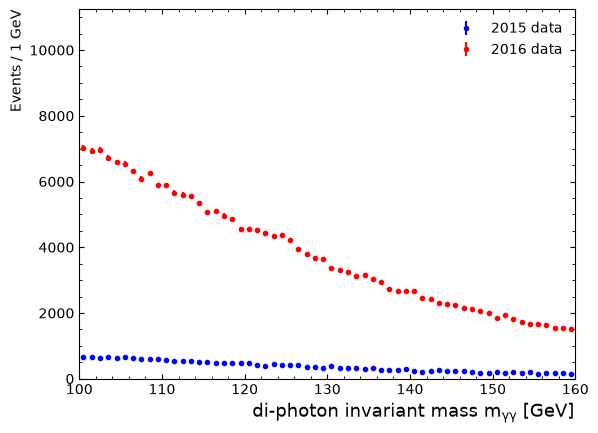

In [22]:

print(f"2015 events (100-160 GeV): {len(masses_2015)}")
print(f"2016 events (100-160 GeV): {len(masses_2016)}")

# Histogram each year
hist_2015, _ = np.histogram(ak.to_numpy(masses_2015), bins=bin_edges)
hist_2016, _ = np.histogram(ak.to_numpy(masses_2016), bins=bin_edges)
err_2015 = np.where(hist_2015 > 0, np.sqrt(hist_2015), 1e-10)
err_2016 = np.where(hist_2016 > 0, np.sqrt(hist_2016), 1e-10)

# Plot both years on the same axes
main_axes = plt.gca()
main_axes.errorbar(x=bin_centres, y=hist_2015, yerr=err_2015,
                    fmt='o', color='blue', label='2015 data', markersize=3)
main_axes.errorbar(x=bin_centres, y=hist_2016, yerr=err_2016,
                    fmt='o', color='red', label='2016 data', markersize=3)

main_axes.set_xlim(left=xmin, right=xmax)
main_axes.xaxis.set_minor_locator(AutoMinorLocator())
main_axes.tick_params(which='both', direction='in', top=True, right=True)
main_axes.set_xlabel(r'di-photon invariant mass $\mathrm{m_{\gamma\gamma}}$ [GeV]',
                      fontsize=13, x=1, horizontalalignment='right')
main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                      y=1, horizontalalignment='right')
main_axes.set_ylim(bottom=0, top=max(np.amax(hist_2015), np.amax(hist_2016))*1.6)
main_axes.yaxis.set_minor_locator(AutoMinorLocator())
main_axes.legend(frameon=False)
plt.show()

In [25]:
# >>> TASK 6b — SOLUTION 2 (optional) <<<
# Process each file separately and group by year and period.
# The filename contains "data15_periodD", "data16_periodK", etc.

period_data = {}

for afile in files_list:
    fname = afile.split("/")[-1]
    print(f'Processing {files_list.index(afile)+1}/{len(files_list)}: {fname}')
    tree = uproot.open(afile + ":analysis")
    numevents = tree.num_entries

    # Extract year and period from the filename
    # e.g. "...data15_periodD..." -> year="2015", period="D"
    if 'data15' in fname:
        year = '2015'
    elif 'data16' in fname:
        year = '2016'
    else:
        continue

    # Find "periodX" in the filename and extract the letter
    period_pos = fname.find('period')
    period = fname[period_pos + 6].upper()  # character after "period"
    label = f'{year} period {period}'

    for data in tree.iterate(variables, library="ak",
                             entry_stop=int(numevents * fraction)):
        # Apply cuts in order (same as Task 6)
        data = data[cut_photon_reconstruction(data['photon_isTightID'])]
        data = data[cut_photon_pt(data['photon_pt'])]
        data = data[cut_isolation_pt(data['photon_ptcone20'], data['photon_pt'])]
        data = data[cut_photon_eta_transition(data['photon_eta'])]

        data['mass'] = calc_mass(data['photon_pt'], data['photon_eta'],
                                 data['photon_phi'], data['photon_e'])
        data = data[cut_mass(data['mass'])]
        data = data[cut_iso_mass(data['photon_pt'], data['mass'])]

        if label not in period_data:
            period_data[label] = []
        period_data[label].append(data['mass'])

# Concatenate the masses for each period
period_masses = {}
for label, sample_data in period_data.items():
    period_masses[label] = ak.concatenate(sample_data)


Processing 1/16: ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root
Processing 2/16: ODEO_FEB2025_v0_GamGam_data15_periodE.GamGam.root
Processing 3/16: ODEO_FEB2025_v0_GamGam_data15_periodF.GamGam.root
Processing 4/16: ODEO_FEB2025_v0_GamGam_data15_periodG.GamGam.root
Processing 5/16: ODEO_FEB2025_v0_GamGam_data15_periodH.GamGam.root
Processing 6/16: ODEO_FEB2025_v0_GamGam_data15_periodJ.GamGam.root
Processing 7/16: ODEO_FEB2025_v0_GamGam_data16_periodA.GamGam.root
Processing 8/16: ODEO_FEB2025_v0_GamGam_data16_periodB.GamGam.root
Processing 9/16: ODEO_FEB2025_v0_GamGam_data16_periodC.GamGam.root
Processing 10/16: ODEO_FEB2025_v0_GamGam_data16_periodD.GamGam.root
Processing 11/16: ODEO_FEB2025_v0_GamGam_data16_periodE.GamGam.root
Processing 12/16: ODEO_FEB2025_v0_GamGam_data16_periodF.GamGam.root
Processing 13/16: ODEO_FEB2025_v0_GamGam_data16_periodG.GamGam.root
Processing 14/16: ODEO_FEB2025_v0_GamGam_data16_periodI.GamGam.root
Processing 15/16: ODEO_FEB2025_v0_GamGam_data16_periodK.G


Period                 Events (100-160 GeV)
--------------------------------------------
2015 period D                           340
2015 period E                          3105
2015 period F                          2103
2015 period G                          5117
2015 period H                          1782
2015 period J                         10039
2016 period A                          3877
2016 period B                         12906
2016 period C                         16342
2016 period D                         33126
2016 period E                         10570
2016 period F                         24424
2016 period G                         27252
2016 period I                         41704
2016 period K                         15520
2016 period L                         43452


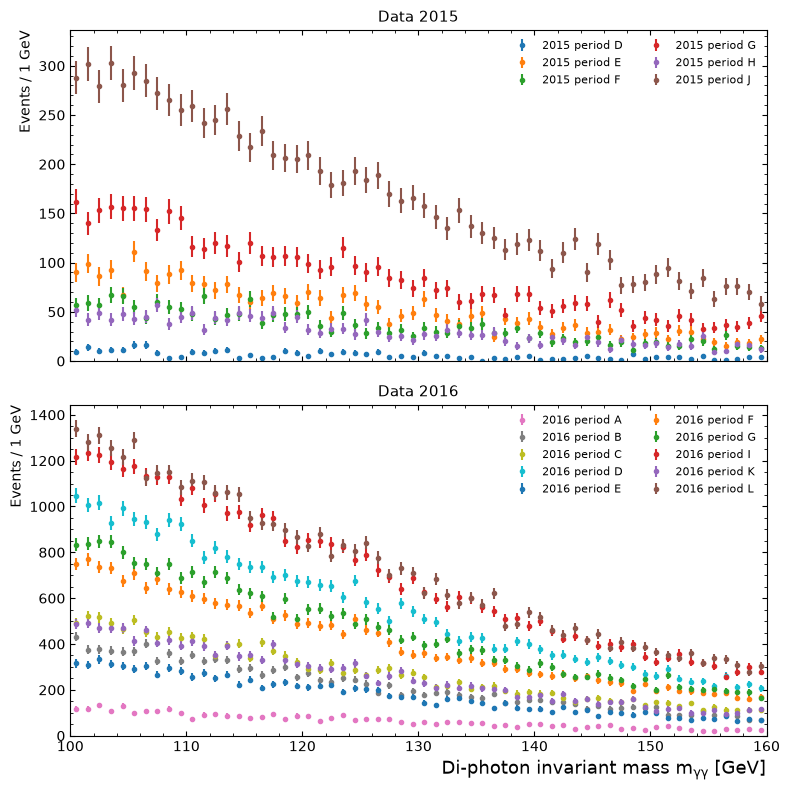

In [26]:

# Print event counts per period
print(f"\n{'Period':<20} {'Events (100-160 GeV)':>22}")
print("-" * 44)
for label in sorted(period_masses):
    m = ak.to_numpy(period_masses[label])
    n = np.sum((m >= xmin) & (m <= xmax))
    print(f"{label:<20} {n:>22}")

# Plot 2015 and 2016 on separate subplots, periods overlaid
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

colours = plt.cm.tab10(np.linspace(0, 1, 10))

for i, label in enumerate(sorted(period_masses)):
    year = label.split()[0]
    ax = axes[0] if year == '2015' else axes[1]

    hist, _ = np.histogram(ak.to_numpy(period_masses[label]), bins=bin_edges)
    err = np.where(hist > 0, np.sqrt(hist), 1e-10)

    ax.errorbar(x=bin_centres, y=hist, yerr=err,
                fmt='o', color=colours[i % 10], label=label, markersize=3)

for ax, year in zip(axes, ['2015', '2016']):
    ax.set_xlim(left=xmin, right=xmax)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.set_ylabel('Events / ' + str(step_size) + ' GeV',
                   y=1, horizontalalignment='right')
    ax.set_ylim(bottom=0)
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.legend(frameon=False, loc='upper right', fontsize=8, ncol=2)
    ax.set_title(f'Data {year}', fontsize=11)

axes[1].set_xlabel(r'Di-photon invariant mass $\mathrm{m_{\gamma\gamma}}$ [GeV]',
                   fontsize=13, x=1, horizontalalignment='right')

plt.tight_layout()
plt.show()

<a id='task7'></a>
## 8. Task 7 — Background-only fit

Before looking for a signal we need a model for the **background**.  The
di-photon mass spectrum is smoothly falling, so a 4th-order polynomial is a
good description:

$$B(m) = c_0 + c_1 m + c_2 m^2 + c_3 m^3 + c_4 m^4$$

<div class="alert alert-block alert-warning">
>>>
<b>TASK 7</b> — Fit the data with a <b>4th-order polynomial only</b> (no
Gaussian).  Store the fit result in <code>out_bkg</code> and the fitted
parameters in a dict.  Print the fitted polynomial coefficients.
</div>

In [14]:
# >>> TASK 7 — SOLUTION <<<
# Background-only model
poly_mod = PolynomialModel(4)
pars_bkg = poly_mod.guess(data_x, x=bin_centres,
                           c0=data_x.max(), c1=0, c2=0, c3=0, c4=0)

out_bkg = poly_mod.fit(data_x, pars_bkg, x=bin_centres,
                        weights=1/data_x_errors)

# Extract coefficients
pdict_bkg = out_bkg.params.valuesdict()
print("Fitted background coefficients:")
for k in ['c0','c1','c2','c3','c4']:
    print(f"  {k} = {pdict_bkg[k]:.6g}")

# Evaluate background on bin centres
background_only = (pdict_bkg['c0']
                    + pdict_bkg['c1']*bin_centres
                    + pdict_bkg['c2']*bin_centres**2
                    + pdict_bkg['c3']*bin_centres**3
                    + pdict_bkg['c4']*bin_centres**4)

print(f"\nBackground-only reduced chi2 = {out_bkg.redchi:.2f}")
print("(Large reduced chi2 indicates structure not captured by background — that's the signal!)")


Fitted background coefficients:
  c0 = -61008.6
  c1 = 2432.89
  c2 = -29.3212
  c3 = 0.144108
  c4 = -0.000253694

Background-only reduced chi2 = 1.42
(Large reduced chi2 indicates structure not captured by background — that's the signal!)


<a id='task8'></a>
## 9. Task 8 — Signal+background fit

Now add a Gaussian signal model on top of the polynomial background.  The
Gaussian describes the Higgs mass peak broadened by the detector's photon
energy resolution.

$$S(m) = \frac{A}{\sigma\sqrt{2\pi}}\exp\!\left(-\frac{(m-\mu)^2}{2\sigma^2}\right)$$

<div class="alert alert-block alert-warning">
>>>
<b>TASK 8</b> — Create a combined <b>polynomial + Gaussian</b> model, fit it to
the data, and extract the fitted Gaussian mean ($\mu$), width ($\sigma$), and
amplitude ($A$).  Store the fit result in <code>out</code>.
</div>

In [15]:
# >>> TASK 8 — SOLUTION <<<
# Combined model
poly_mod = PolynomialModel(4)
gauss_mod = GaussianModel()

# Initial guesses
pars  = poly_mod.guess(data_x, x=bin_centres, c0=data_x.max(),
                       c1=0, c2=0, c3=0, c4=0)
pars += gauss_mod.guess(data_x, x=bin_centres,
                          amplitude=100, center=125, sigma=2)

model = poly_mod + gauss_mod

# Fit
out = model.fit(data_x, pars, x=bin_centres, weights=1/data_x_errors)

# Extract signal parameters
p = out.params.valuesdict()
mu_fit   = p['center']
sigma_fit = p['sigma']
amp_fit   = p['amplitude']

# Extract background coefficients
c0, c1, c2, c3, c4 = p['c0'], p['c1'], p['c2'], p['c3'], p['c4']

# Evaluate background component
background = (c0 + c1*bin_centres + c2*bin_centres**2
              + c3*bin_centres**3 + c4*bin_centres**4)

# Data - background = signal residual
signal_x = data_x - background

print("=== Signal+Background Fit Results ===")
print(f"Gaussian mean (mu):     {mu_fit:.2f} GeV")
print(f"Gaussian width (sigma):  {sigma_fit:.2f} GeV")
print(f"Gaussian amplitude:        {amp_fit:.1f}")
print(f"Reduced chi2:            {out.redchi:.2f}")


=== Signal+Background Fit Results ===
Gaussian mean (mu):     124.72 GeV
Gaussian width (sigma):  1.20 GeV
Gaussian amplitude:        873.7
Reduced chi2:            0.91


<a id='task9'></a>
## 10. Task 9 — Residuals and reduced $\chi^2$

A **residual plot** (Data − Background) is the standard way to visualise the
signal component.  The reduced $\chi^2$ tells us how well the fit describes the
data.

$$\chi^2 = \sum_i \frac{(N_i - f_i)^2}{\sigma_i^2}, \qquad
\chi^2_{\text{red}} = \frac{\chi^2}{N_{\text{bins}} - N_{\text{params}}}$$

<div class="alert alert-block alert-warning">
>>>
<b>TASK 9</b> —
<ol>
<li>Compute the residuals <code>data_x - background</code> and plot them as
error points.</li>
<li>Overlay the fitted signal component <code>out.best_fit - background</code>.</li>
<li>Compute the reduced $\chi^2$ from the fit result and print it.</li>
</ol>
</div>

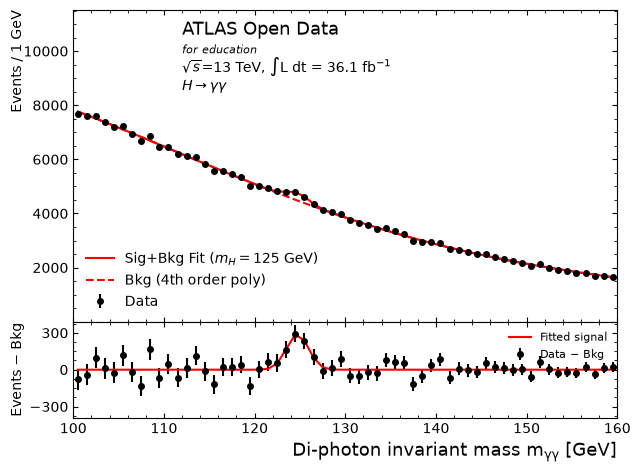

Chi2           = 47.2
NDF            = 52
Reduced chi2   = 0.91
A reduced chi2 close to 1 means the model describes the data well.


In [16]:
# >>> TASK 9 — SOLUTION <<<
# Residuals: data minus background-only component
residuals = data_x - background
residual_errors = data_x_errors

# Signal component from the fit
signal_component = out.best_fit - background

# --- Main plot: data + total fit + background ---
plt.axes([0.1, 0.3, 0.85, 0.65])
main_axes = plt.gca()

main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
                   fmt='ko', label='Data', markersize=4)
main_axes.plot(bin_centres, out.best_fit, '-r',
                label='Sig+Bkg Fit ($m_H=125$ GeV)')
main_axes.plot(bin_centres, background, '--r',
               label='Bkg (4th order poly)')

main_axes.set_xlim(left=xmin, right=xmax)
main_axes.xaxis.set_minor_locator(AutoMinorLocator())
main_axes.tick_params(which='both', direction='in', top=True, right=True,
                       labelbottom=False)
main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                      horizontalalignment='right')
main_axes.set_ylim(bottom=0, top=np.amax(data_x)*1.5)
main_axes.yaxis.set_minor_locator(AutoMinorLocator())
main_axes.yaxis.get_major_ticks()[0].set_visible(False)

plt.text(0.2, 0.92, 'ATLAS Open Data', transform=main_axes.transAxes, fontsize=13)
plt.text(0.2, 0.86, 'for education', transform=main_axes.transAxes,
         style='italic', fontsize=8)
plt.text(0.2, 0.80,
         r'$\sqrt{s}$=13 TeV, $\int$L dt = '+str(luminosity*fraction)+' fb$^{-1}$',
         transform=main_axes.transAxes)
plt.text(0.2, 0.74, r'$H \rightarrow \gamma\gamma$', transform=main_axes.transAxes)

main_axes.legend(frameon=False, loc='lower left')

# --- Sub plot: residuals ---
plt.axes([0.1, 0.1, 0.85, 0.2])
sub_axes = plt.gca()
sub_axes.yaxis.set_major_locator(MaxNLocator(nbins='auto', symmetric=True))

# Plot residuals
sub_axes.errorbar(x=bin_centres, y=residuals, yerr=residual_errors,
                   fmt='ko', markersize=4, label='Data − Bkg')
# Plot fitted signal component
sub_axes.plot(bin_centres, signal_component, '-r', label='Fitted signal')

sub_axes.set_xlim(left=xmin, right=xmax)
sub_axes.xaxis.set_minor_locator(AutoMinorLocator())
sub_axes.set_xlabel(r'Di-photon invariant mass $\mathrm{m_{\gamma\gamma}}$ [GeV]',
                     x=1, horizontalalignment='right', fontsize=13)
sub_axes.tick_params(which='both', direction='in', top=True, right=True)
sub_axes.yaxis.set_minor_locator(AutoMinorLocator())
sub_axes.set_ylabel('Events − Bkg')
sub_axes.legend(frameon=False, loc='upper right', fontsize=8)

main_axes.yaxis.set_label_coords(-0.09, 1)
sub_axes.yaxis.set_label_coords(-0.09, 0.5)

plt.show()

# --- Reduced chi^2 ---
chi2      = out.chisqr
ndof       = out.nfree
red_chi2   = out.redchi
print(f"Chi2           = {chi2:.1f}")
print(f"NDF            = {ndof}")
print(f"Reduced chi2   = {red_chi2:.2f}")
print(f"A reduced chi2 close to 1 means the model describes the data well.")


<a id='task10'></a>
## 11. Task 10 — Signal yield and excess estimate

We can estimate the number of signal events in the Higgs peak by comparing
the data to the background-only fit in a **signal window** around the fitted
mean.

<div class="alert alert-block alert-warning">
>>>
<b>TASK 10</b> —
<ol>
<li>Define a signal window of $\mu \pm 2\sigma$ around the fitted Gaussian
mean.</li>
<li>Count the data events in this window.</li>
<li>Integrate the background-only fit over the same window.</li>
<li>Compute the excess: <code>N_signal = N_data − N_background</code>.</li>
<li>Estimate a simple "significance" as
$S / \sqrt{B}$ where $S$ is the excess and $B$ is the background.</li>
<li>Print all these numbers.</li>
</ol>
</div>

In [17]:
# >>> TASK 10 — SOLUTION <<<
# Signal window: mu +/- 2*sigma
window_lo = mu_fit - 2 * sigma_fit
window_hi = mu_fit + 2 * sigma_fit
print(f"Signal window: {window_lo:.1f} – {window_hi:.1f} GeV "
      f"(mu={mu_fit:.2f}, sigma={sigma_fit:.2f})")

# Data events in window
in_window = (bin_centres >= window_lo) & (bin_centres <= window_hi)
n_data_window  = np.sum(data_x[in_window])
n_bkg_window   = np.sum(background[in_window])
n_signal        = n_data_window - n_bkg_window

# Simple significance: S / sqrt(B)
significance = n_signal / np.sqrt(max(n_bkg_window, 1e-10))

print(f"\n--- Signal window ({window_lo:.1f}–{window_hi:.1f} GeV) ---")
print(f"Data events:         {n_data_window}")
print(f"Background (from fit): {n_bkg_window:.1f}")
print(f"Excess (S):           {n_signal:.1f} events")
print(f"Significance (S/sqrt(B)): {significance:.2f}")
print(f"\nA clear positive excess above the background indicates the Higgs signal.")


Signal window: 122.3 – 127.1 GeV (mu=124.72, sigma=1.20)

--- Signal window (122.3–127.1 GeV) ---
Data events:         23384
Background (from fit): 22537.2
Excess (S):           846.8 events
Significance (S/sqrt(B)): 5.64

A clear positive excess above the background indicates the Higgs signal.


<a id='task11'></a>
## 12. Task 11 — Sideband cross-check

A **sideband cross-check** compares the data and the background model in
regions **away** from the signal peak.  If the background model is good, the
data in the sidebands should agree with the background prediction.

<div class="alert alert-block alert-warning">
>>>
<b>TASK 11</b> —
<ol>
<li>Define two sideband regions: 105–120 GeV (low) and 130–155 GeV (high).</li>
<li>Count data events and background events in each sideband.</li>
<li>Compute the ratio <code>Data / Background</code> in each sideband.  A ratio
close to 1 means the background model is working well.</li>
<li>Print the results.</li>
</ol>
</div>

In [18]:
# >>> TASK 11 — SOLUTION <<<
# Sideband regions (avoid the 120-130 GeV signal window)
lo_side = (bin_centres >= 105) & (bin_centres < 120)
hi_side = (bin_centres > 130) & (bin_centres <= 155)

# Data vs background in each sideband
n_data_lo = np.sum(data_x[lo_side])
n_bkg_lo  = np.sum(background[lo_side])

n_data_hi = np.sum(data_x[hi_side])
n_bkg_hi  = np.sum(background[hi_side])

ratio_lo = n_data_lo / n_bkg_lo if n_bkg_lo > 1e-10 else float('nan')
ratio_hi = n_data_hi / n_bkg_hi if n_bkg_hi > 1e-10 else float('nan')

print("--- Sideband cross-check ---")
print(f"Low sideband (105-120 GeV):  Data={n_data_lo}, Bkg={n_bkg_lo:.1f}, "
      f"Data/Bkg={ratio_lo:.3f}")
print(f"High sideband (130-155 GeV): Data={n_data_hi}, Bkg={n_bkg_hi:.1f}, "
      f"Data/Bkg={ratio_hi:.3f}")
print()
print("If the ratios are close to 1, the background model is reliable.")
print("Any large deviation would suggest the polynomial order is not sufficient.")


--- Sideband cross-check ---
Low sideband (105-120 GeV):  Data=91855, Bkg=91862.0, Data/Bkg=1.000
High sideband (130-155 GeV): Data=68106, Bkg=68146.2, Data/Bkg=0.999

If the ratios are close to 1, the background model is reliable.
Any large deviation would suggest the polynomial order is not sufficient.


<a id='task12'></a>
## 13. Task 12 — Limit-setting reasoning

In a real analysis, we ask: *"If there were **no** Higgs boson, how likely
would we be to see an excess this large?"*

We won't do heavy statistics here, but we can reason about the ingredients and
estimate an "upper limit" on the signal yield using a simple **counting
experiment**.

### Simple counting experiment

In the signal window $[\mu - 2\sigma, \mu + 2\sigma]$:
* $N_{\text{data}}$ — observed data events
* $N_{\text{bkg}}$ — expected background (from the fit)
* $S_{\text{obs}} = N_{\text{data}} - N_{\text{bkg}}$ — observed excess

If there were no Higgs, the data would fluctuate around $N_{\text{bkg}}$ with
uncertainty $\sqrt{N_{\text{bkg}}}$.  An **approximate 95% confidence-level
upper limit** on the signal yield can be estimated as:

$$S_{\text{limit}}^{95\%} \approx S_{\text{obs}} + 1.64\,\sqrt{N_{\text{bkg}}}$$

*(The factor 1.64 corresponds to the one-sided 95% quantile of a Gaussian.)*

<div class="alert alert-block alert-warning">
>>>
<b>TASK 12</b> —
<ol>
<li>Using the numbers from Task 10, compute $S_{\text{obs}}$ and
$S_{\text{limit}}^{95\%}$.</li>
<li>Print both values and comment on whether the observed excess exceeds the
expected limit (i.e. whether we would claim a "discovery-like" observation).</li>
</ol>
</div>

In [19]:
# >>> TASK 12 — SOLUTION <<<
# Re-use the signal-window quantities from Task 10
N_data   = n_data_window
N_bkg    = n_bkg_window
S_obs    = N_data - N_bkg

# Approximate 95% CL upper limit on the signal yield
S_limit_95 = S_obs + 1.64 * np.sqrt(max(N_bkg, 1e-10))

print("=== Simple counting-experiment limit ===")
print(f"Signal window:       {window_lo:.1f} – {window_hi:.1f} GeV")
print(f"Observed data (N):   {N_data}")
print(f"Background (B):      {N_bkg:.1f}")
print(f"Observed excess (S):  {S_obs:.1f} events")
print(f"Stat. uncertainty on B (sqrt(B)): {np.sqrt(max(N_bkg,1e-10)):.1f}")
print()
print(f"Approximate 95% CL upper limit on signal: {S_limit_95:.1f} events")
print()
if S_obs > 1.64 * np.sqrt(max(N_bkg, 1e-10)):
    print("The observed excess exceeds the 95% CL expectation → "
          "evidence for a signal (Higgs!).")
else:
    print("The observed excess is below the 95% CL expectation → "
          "no significant signal claimed.")


=== Simple counting-experiment limit ===
Signal window:       122.3 – 127.1 GeV
Observed data (N):   23384
Background (B):      22537.2
Observed excess (S):  846.8 events
Stat. uncertainty on B (sqrt(B)): 150.1

Approximate 95% CL upper limit on signal: 1093.0 events

The observed excess exceeds the 95% CL expectation → evidence for a signal (Higgs!).


<a id='task13'></a>
## 14. Task 13 — Optional: vary a cut and study the effect

A good analyst always checks how robust the result is against cut variations.

<div class="alert alert-block alert-warning">
>>>
<b>TASK 13 (optional)</b> — Re-run the analysis but change the leading-photon
$p_T$ cut from 50 GeV to <b>35 GeV</b>.  Observe how the number of selected
events changes and whether the Higgs peak becomes more or less visible.
</div>

In [20]:
# >>> TASK 13 — SOLUTION (optional) <<<
# We only re-run the first file for speed and just compare event counts.
# The new pT cut is lower, so we expect MORE events (more background too).

def cut_photon_pt_loose(photon_pt):
    """Looser pT cut: leading > 35, sub-leading > 20 GeV."""
    return (photon_pt[:, 0] > 35) & (photon_pt[:, 1] > 20)

n_tight = 0
n_loose = 0

tree = uproot.open(files_list[0] + ":analysis")
for data in tree.iterate(variables, library="ak"):
    # Tight selection (original)
    d_t = data[cut_photon_reconstruction(data['photon_isTightID'])]
    d_t = d_t[cut_photon_pt(d_t['photon_pt'])]
    d_t = d_t[cut_isolation_pt(d_t['photon_ptcone20'], d_t['photon_pt'])]
    d_t = d_t[cut_photon_eta_transition(d_t['photon_eta'])]
    d_t['mass'] = calc_mass(d_t['photon_pt'], d_t['photon_eta'],
                            d_t['photon_phi'], d_t['photon_e'])
    d_t = d_t[cut_mass(d_t['mass'])]
    d_t = d_t[cut_iso_mass(d_t['photon_pt'], d_t['mass'])]
    n_tight += len(d_t)

    # Loose selection
    d_l = data[cut_photon_reconstruction(data['photon_isTightID'])]
    d_l = d_l[cut_photon_pt_loose(d_l['photon_pt'])]
    d_l = d_l[cut_isolation_pt(d_l['photon_ptcone20'], d_l['photon_pt'])]
    d_l = d_l[cut_photon_eta_transition(d_l['photon_eta'])]
    d_l['mass'] = calc_mass(d_l['photon_pt'], d_l['photon_eta'],
                            d_l['photon_phi'], d_l['photon_e'])
    d_l = d_l[cut_mass(d_l['mass'])]
    d_l = d_l[cut_iso_mass(d_l['photon_pt'], d_l['mass'])]
    n_loose += len(d_l)

print(f"Events with TIGHT pT cut (50/30 GeV): {n_tight}")
print(f"Events with LOOSE pT cut (35/20 GeV): {n_loose}")
print(f"Ratio loose/tight: {n_loose/n_tight:.2f}")
print("A looser cut keeps more signal but also much more background.")


Events with TIGHT pT cut (50/30 GeV): 790
Events with LOOSE pT cut (35/20 GeV): 2186
Ratio loose/tight: 2.77
A looser cut keeps more signal but also much more background.


---

## Summary

In this notebook you have:

1. **Explored** the ATLAS Open Data TTree structure.
2. **Implemented** five photon selection cuts.
3. **Built a cut-flow table** showing the effect of each cut.
4. **Computed** the di-photon invariant mass.
5. **Histogrammed** the full dataset after all cuts.
6. **Fitted** the background with a 4th-order polynomial.
7. **Fitted** the signal+background with a Gaussian + polynomial.
8. **Plotted residuals** and computed the reduced $\chi^2$.
9. **Estimated** the signal yield and a simple significance.
10. **Cross-checked** the background model in sidebands.
11. **Estimated** an approximate 95% CL upper limit on the signal yield.

The Higgs boson should be clearly visible as a peak around 125 GeV — you have
rediscovered it!

---

### Going further
* Try different polynomial orders (2nd, 3rd) for the background and compare the reduced $\chi^2$.
* Try different initial guesses for the Gaussian parameters and see if the fit converges to the same values.
* Compute the signal yield in a narrower window ($\mu \pm 1\sigma$) and compare.
* Process all the data (set `fraction = 1.0`) and compare the significance.

<div class="alert alert-block alert-info">
We welcome your feedback on this notebook or any of our other materials! Please
<a href="https://forms.gle/zKBqS1opAHHemv9U7">fill out this survey</a> to let us
know how we're doing, and you can enter a raffle to win some
<a href="https://atlas-secretariat.web.cern.ch/merchandise">ATLAS merchandise</a>!
</div>
